In [1]:
import os
import sys
import pickle
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path("/Users/radinabakalov/TECHTRACK-RADINABAKALOV")
sys.path.append(str(REPO_ROOT))

from techtrack.modules.inference.model import Detector
from techtrack.modules.inference.nms import NMS

In [2]:
# Paths (same layout as the other task notebooks)
DATA_DIR = REPO_ROOT / "techtrack" / "storage" / "logistics"
SAMPLE_LIST = REPO_ROOT / "analysis" / "sample_images.txt"
MODEL2_DIR = REPO_ROOT / "techtrack" / "storage" / "yolo_model_2"
CACHE_DIR = REPO_ROOT / "analysis" / "cache"
FIG_DIR = REPO_ROOT / "analysis" / "figures"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Class names
CLASS_NAMES = [
    "barcode", "car", "cardboard box", "fire", "forklift",
    "freight container", "gloves", "helmet", "ladder", "license plate",
    "person", "qr code", "road sign", "safety vest", "smoke",
    "traffic cone", "traffic light", "truck", "van", "wood pallet",
]

# Load the sampled image list we built in Task 2
# (same 6000 images used across all tasks for consistency)
with open(SAMPLE_LIST, "r") as f:
    sample_paths = [Path(line.strip()) for line in f if line.strip()]

print(f"Sample size: {len(sample_paths)} images")

Sample size: 6000 images


In [3]:
# Build Model 2 and NMS with the best threshold from Task 3
# Only keep detections the model is at least 50% confident about
SCORE_THRESHOLD = 0.5
BEST_NMS_THRESHOLD = 0.5  

# Point to the weights, config, and class names for Model 2
weights = MODEL2_DIR / "yolov4-tiny-logistics_size_416_2.weights"
cfg = MODEL2_DIR / "yolov4-tiny-logistics_size_416_2.cfg"
names = MODEL2_DIR / "logistics.names"

# Load the detector with our confidence threshold
det2 = Detector(str(weights), str(cfg), str(names), score_threshold=SCORE_THRESHOLD)
nms = NMS(score_threshold=SCORE_THRESHOLD, nms_iou_threshold=BEST_NMS_THRESHOLD)

print("Model 2 loaded.")

Model 2 loaded.


In [4]:
def get_label_path(img_path: Path):
    """Swap .jpg to .txt to find the matching YOLO label file."""
    return Path(img_path).with_suffix(".txt")


def yolo_txt_to_boxes(txt_path: Path, img_w: int, img_h: int):
    """
    Parse a YOLO .txt label file into pixel-space bounding boxes.
    Returns (gt_boxes, gt_classes) where boxes are [x, y, w, h] in pixels.
    """
    # If there's no label file, this image has no annotations
    if not txt_path.exists():
        return [], []

    gt_boxes = []
    gt_classes = []

    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            # Each valid YOLO line has exactly 5 values (class cx cy w h)
            if len(parts) != 5:
                continue

            cls = int(float(parts[0]))
            # YOLO stores coordinates as normalized center-x, center-y, width, height
            cx, cy, w, h = map(float, parts[1:])

            # Convert from normalized center format to pixel corner format
            # (top-left x, top-left y, box width, box height)
            bw = int(round(w * img_w))
            bh = int(round(h * img_h))
            x = int(round((cx * img_w) - bw / 2))
            y = int(round((cy * img_h) - bh / 2))

            gt_boxes.append([x, y, bw, bh])
            gt_classes.append(cls)

    return gt_boxes, gt_classes


def iou_xywh(a, b):
    """Compute Intersection over Union for two boxes in [x, y, w, h] format."""
    # Unpack both boxes
    ax, ay, aw, ah = a
    bx, by, bw, bh = b

    # Get the bottom-right corners of each box
    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    # Find the overlap rectangle (if any)
    ix1 = max(ax, bx)
    iy1 = max(ay, by)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    # To zero (if the boxes don't overlap, the width/height will be negative)
    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    # Union = both areas combined, minus the overlap we counted twice
    union = max(0, aw) * max(0, ah) + max(0, bw) * max(0, bh) - inter
    
    # Avoid division by zero if something slipped in
    return (inter / union) if union > 0 else 0.0

In [5]:
def eval_predictions(preds, iou_thr=0.5, num_classes=20):
    """
    Evaluate predictions against ground truth using greedy IoU matching.
    Returns a DataFrame with per-class precision, recall, and F1.
    """
    # Per-class counters for the confusion breakdown
    tp = np.zeros(num_classes, dtype=int) # correctly detected
    fp = np.zeros(num_classes, dtype=int) # predicted but wrong
    fn = np.zeros(num_classes, dtype=int) # missed entirely

    for row in preds:
        img_path = Path(row["img_path"])
        pred = row["pred"]
        img_h = row["img_h"]
        img_w = row["img_w"]

        # Load GT boxes (use original labels, even for augmented images)
        gt_boxes, gt_classes = yolo_txt_to_boxes(
            get_label_path(img_path), img_w, img_h
        )

        # Flip GT boxes vertically if this was a vertical flip run
        if row.get("vflip", False):
            gt_boxes = [[x, img_h - y - h, w, h] for x, y, w, h in gt_boxes]

        # If the detector returned nothing, every ground truth box is a mis
        if pred is None:
            for c in gt_classes:
                fn[c] += 1
            continue

        pred_boxes = pred["bboxes"]
        pred_classes = pred["class_ids"]

        # Track which ground truth boxes have already been claimed
        matched_gt = [False] * len(gt_boxes)

        # Greedy matching
        # For each predicted box, find the best-overlapping GT box of the same class that hasn't been matched yet
        for pb, pc in zip(pred_boxes, pred_classes):
            best_iou, best_j = 0.0, -1

            for j, (gb, gc) in enumerate(zip(gt_boxes, gt_classes)):
                # Skip GTs that are already taken or a different class
                if matched_gt[j] or gc != pc:
                    continue
                cur_iou = iou_xywh(pb, gb)
                if cur_iou > best_iou:
                    best_iou = cur_iou
                    best_j = j

            # Good enough overlap? Count it as a hit
            if best_iou >= iou_thr and best_j != -1:
                tp[pc] += 1
                matched_gt[best_j] = True
            else:
                # Either no match or IoU too low, then it's a false positive
                fp[pc] += 1

        # Any GT box that nobody claimed is a false negative
        for j, gc in enumerate(gt_classes):
            if not matched_gt[j]:
                fn[gc] += 1

    # Compute metrics from the raw counts
    # np.maximum avoids division by zero for classes with no predictions/labels
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / np.maximum(tp + fn, 1)
    f1 = (2 * precision * recall) / np.maximum(precision + recall, 1e-9)

    return pd.DataFrame({
        "class_id": np.arange(num_classes),
        "tp": tp, "fp": fp, "fn": fn,
        "precision": precision, "recall": recall, "f1": f1,
    })

In [6]:
def apply_gaussian_blur(img, kernel_size):
    """Blur the image with a Gaussian kernel. Larger kernel = more blur."""
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)


def apply_vertical_flip(img):
    """Flip the image upside down."""
    return cv2.flip(img, 0)


def apply_brightness(img, factor):
    """
    Scale image brightness by a factor.
    factor < 1.0 = darker, factor > 1.0 = brighter.
    Uses addWeighted to keep pixel values in the valid [0, 255] range.
    """
    # Blend the original image with a pure black image at the given ratio
    dark = np.zeros_like(img)
    return cv2.addWeighted(img, factor, dark, 1.0 - factor, 0)

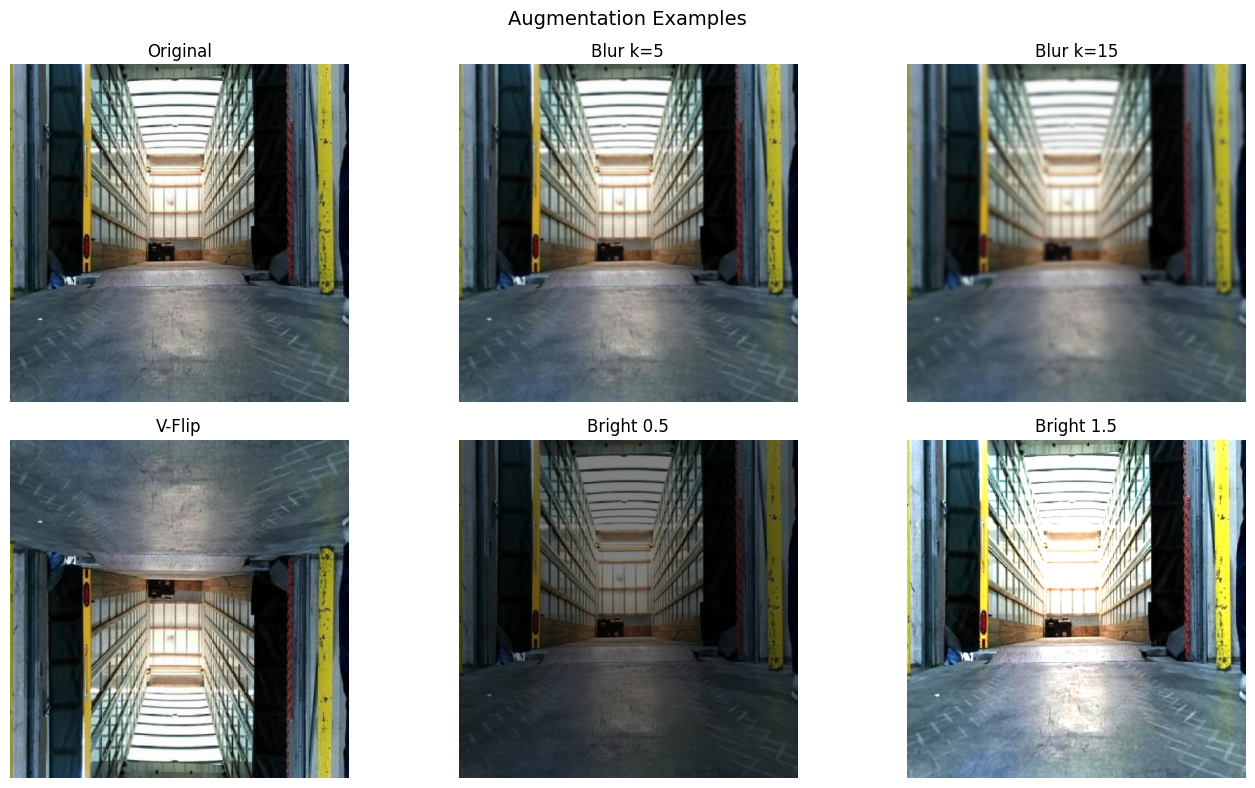

In [7]:
# Quick check to show one image with each augmentation
# so we can verify they look right before running the full evaluation
sample_img = cv2.imread(str(sample_paths[0]))

# Build a gallery of the original + all augmented variants
augs = [
    ("Original", sample_img),
    ("Blur k=5", apply_gaussian_blur(sample_img, 5)),
    ("Blur k=15", apply_gaussian_blur(sample_img, 15)),
    ("V-Flip", apply_vertical_flip(sample_img)),
    ("Bright 0.5", apply_brightness(sample_img, 0.5)),
    ("Bright 1.5", apply_brightness(sample_img, 1.5)),
]

# Display them in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (title, img) in zip(axes.flat, augs):
    # OpenCV loads BGR, matplotlib expects RGB
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Augmentation Examples", fontsize=14)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "augmentation_examples.png"), dpi=150, bbox_inches="tight")
plt.show()

In [8]:
def run_augmented_eval(aug_name, aug_fn, sample_paths, detector, nms, cache_dir, vflip=False):
    """
    Apply an augmentation to every sample image, run detection, and evaluate.
    Caches the raw predictions so we only run inference once per augmentation (saves a ton of time on repeat runs).
    """
    cache_file = cache_dir / f"aug_{aug_name}_preds.pkl"

    # If we already ran this augmentation, just load from cache
    if cache_file.exists():
        with open(cache_file, "rb") as f:
            preds = pickle.load(f)
        print(f"  Loaded cached predictions for '{aug_name}'")
    else:
        # No cache so we run inference on every augmented image
        preds = []
        for i, img_path in enumerate(sample_paths, 1):
            img = cv2.imread(str(img_path))
            if img is None:
                # If the image is corrupt or missing, record a blank entry
                preds.append({"img_path": str(img_path), "pred": None,
                              "img_h": 0, "img_w": 0, "vflip": vflip})
                continue

            img_h, img_w = img.shape[:2]

            # Apply the augmentation to the image
            aug_img = aug_fn(img)

            # Run detection on the augmented version
            outputs = detector.predict(aug_img)
            bboxes, class_ids, scores, cls_scores = detector.post_process(outputs)

            # Apply NMS to filter overlapping boxes
            bboxes, class_ids, scores, cls_scores = nms.filter(
                bboxes, class_ids, scores, cls_scores
            )

            # If NMS removed everything, treat it as no detections
            pred = {
                "bboxes": bboxes, "class_ids": class_ids,
                "scores": scores, "cls_scores": cls_scores,
            } if bboxes else None

            preds.append({
                "img_path": str(img_path), "pred": pred,
                "img_h": img_h, "img_w": img_w, "vflip": vflip,
            })

            # Progress update every 500 images
            if i % 500 == 0:
                print(f"    {aug_name}: {i}/{len(sample_paths)}")

        # Save to disk so future runs are instant
        with open(cache_file, "wb") as f:
            pickle.dump(preds, f)
        print(f"  Cached predictions for '{aug_name}'")

    # Evaluate the predictions against ground truth
    df = eval_predictions(preds)
    return df

In [9]:
# Define all the augmentation experiments we want to run
# Each entry is: (display name, augmentation function, is_vflip?)
# The vflip flag is needed so eval knows to flip GT boxes too
experiments = [
    # Baseline (no augmentation) -> this is our control group
    ("baseline", lambda img: img, False),
    
    # Gaussian blur at increasing kernel sizes -> simulates camera focus issues or motion blur
    ("blur_k3", lambda img: apply_gaussian_blur(img, 3), False),
    ("blur_k5", lambda img: apply_gaussian_blur(img, 5), False),
    ("blur_k9", lambda img: apply_gaussian_blur(img, 9), False),
    ("blur_k15", lambda img: apply_gaussian_blur(img, 15), False),
    ("blur_k21", lambda img: apply_gaussian_blur(img, 21), False),

    # Vertical flip -> tests if the model is orientation-dependent
    ("vflip", lambda img: apply_vertical_flip(img), True),
    
    # Brightness at different factors -> simulates lighting variation
    # Below 1.0 = darker (underexposed), above 1.0 = brighter (overexposed)
    ("bright_0.25", lambda img: apply_brightness(img, 0.25), False),
    ("bright_0.50", lambda img: apply_brightness(img, 0.50), False),
    ("bright_0.75", lambda img: apply_brightness(img, 0.75), False),
    ("bright_1.25", lambda img: apply_brightness(img, 1.25), False),
    ("bright_1.50", lambda img: apply_brightness(img, 1.50), False),
    ("bright_2.00", lambda img: apply_brightness(img, 2.00), False),
]

In [10]:
# Run all augmentation experiments 
# (takes a while the first time, but everything gets cached so reruns are instant)
all_results = {}

for aug_name, aug_fn, is_vflip in experiments:
    print(f"Running: {aug_name}")
    df = run_augmented_eval(aug_name, aug_fn, sample_paths, det2, nms, CACHE_DIR, vflip=is_vflip)

    # Compute macro-averaged metrics (treats every class equally)
    macro_prec = df["precision"].mean()
    macro_rec = df["recall"].mean()
    macro_f1 = df["f1"].mean()

    # Store everything including the full per-class DataFrame for later use
    all_results[aug_name] = {
        "precision": macro_prec,
        "recall": macro_rec,
        "f1": macro_f1,
        "df": df, # keep per-class details for later
    }
    print(f"  P={macro_prec:.4f}  R={macro_rec:.4f}  F1={macro_f1:.4f}\n")

print("All experiments complete.")

Running: baseline
  Loaded cached predictions for 'baseline'
  P=0.8204  R=0.5267  F1=0.6194

Running: blur_k3
  Loaded cached predictions for 'blur_k3'
  P=0.8535  R=0.4814  F1=0.5907

Running: blur_k5
  Loaded cached predictions for 'blur_k5'
  P=0.8626  R=0.4369  F1=0.5527

Running: blur_k9
  Loaded cached predictions for 'blur_k9'
  P=0.8717  R=0.3488  F1=0.4638

Running: blur_k15
  Loaded cached predictions for 'blur_k15'
  P=0.8814  R=0.2765  F1=0.3834

Running: blur_k21
  Loaded cached predictions for 'blur_k21'
  P=0.8453  R=0.2192  F1=0.3126

Running: vflip
  Loaded cached predictions for 'vflip'
  P=0.6665  R=0.2540  F1=0.3091

Running: bright_0.25
  Loaded cached predictions for 'bright_0.25'
  P=0.8413  R=0.4463  F1=0.5523

Running: bright_0.50
  Loaded cached predictions for 'bright_0.50'
  P=0.8335  R=0.5092  F1=0.6070

Running: bright_0.75
  Loaded cached predictions for 'bright_0.75'
  P=0.8223  R=0.5264  F1=0.6193

Running: bright_1.25
  Loaded cached predictions for '

In [11]:
# Build a clean summary table for the report
summary_rows = []
for aug_name, metrics in all_results.items():
    summary_rows.append({
        "augmentation": aug_name,
        "precision": round(metrics["precision"], 4),
        "recall": round(metrics["recall"], 4),
        "f1": round(metrics["f1"], 4),
    })

summary_df = pd.DataFrame(summary_rows)

# Add a delta column showing how much each augmentation changed F1
# compared to the unmodified baseline -> positive = improvement, negative = hurt
baseline_f1 = all_results["baseline"]["f1"]
summary_df["f1_delta"] = (summary_df["f1"] - baseline_f1).round(4)

summary_df

,augmentation,precision,recall,f1,f1_delta
0,baseline,0.8204,0.5267,0.6194,0.0000
1,blur_k3,0.8535,0.4814,0.5907,-0.0287
2,blur_k5,0.8626,0.4369,0.5527,-0.0667
3,blur_k9,0.8717,0.3488,0.4638,-0.1556
4,blur_k15,0.8814,0.2765,0.3834,-0.2360
5,blur_k21,0.8453,0.2192,0.3126,-0.3068
6,vflip,0.6665,0.2540,0.3091,-0.3103
7,bright_0.25,0.8413,0.4463,0.5523,-0.0671
8,bright_0.50,0.8335,0.5092,0.6070,-0.0124
9,bright_0.75,0.8223,0.5264,0.6193,-0.0001


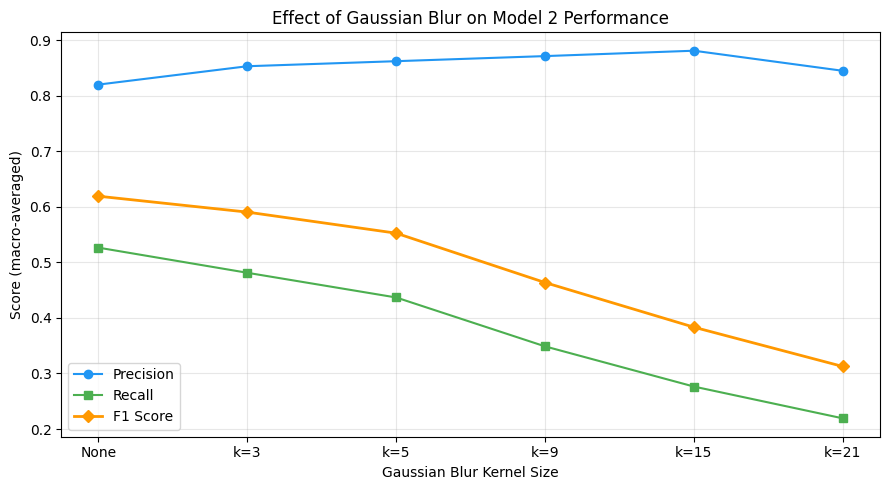

In [12]:
# Pull out the blur experiment results in order of increasing kernel size
blur_names = ["baseline", "blur_k3", "blur_k5", "blur_k9", "blur_k15", "blur_k21"]
blur_labels = ["None", "k=3", "k=5", "k=9", "k=15", "k=21"]

# Gather the macro-averaged metrics for each blur level
blur_f1 = [all_results[n]["f1"] for n in blur_names]
blur_prec = [all_results[n]["precision"] for n in blur_names]
blur_rec = [all_results[n]["recall"] for n in blur_names]

fig, ax = plt.subplots(figsize=(9, 5))

# Plot all three metrics to see how blur degrades performance
ax.plot(blur_labels, blur_prec, "o-", label="Precision", color="#2196F3")
ax.plot(blur_labels, blur_rec, "s-", label="Recall", color="#4CAF50")
ax.plot(blur_labels, blur_f1, "D-", label="F1 Score", color="#FF9800", linewidth=2)

ax.set_xlabel("Gaussian Blur Kernel Size")
ax.set_ylabel("Score (macro-averaged)")
ax.set_title("Effect of Gaussian Blur on Model 2 Performance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "aug_blur_impact.png"), dpi=150, bbox_inches="tight")
plt.show()

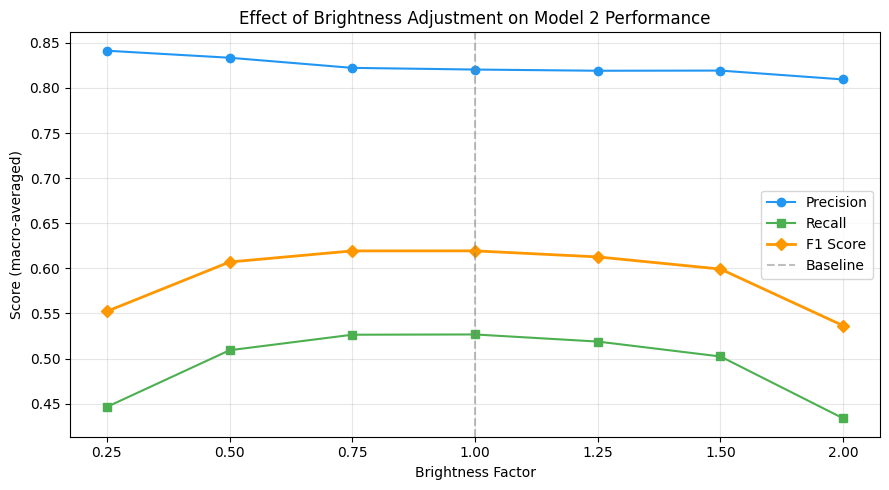

In [13]:
# Pull out the brightness experiment results, ordered from darkest to brightest
# (baseline sits at 1.00 in the middle so that's the unmodified image)
bright_names = ["bright_0.25", "bright_0.50", "bright_0.75", "baseline", "bright_1.25", "bright_1.50", "bright_2.00"]
bright_labels = ["0.25", "0.50", "0.75", "1.00", "1.25", "1.50", "2.00"]

# Gather macro-averaged metrics for each brightness level
bright_f1 = [all_results[n]["f1"] for n in bright_names]
bright_prec = [all_results[n]["precision"] for n in bright_names]
bright_rec = [all_results[n]["recall"] for n in bright_names]

fig, ax = plt.subplots(figsize=(9, 5))

# Plot all three metrics to see how lighting changes affect detection
ax.plot(bright_labels, bright_prec, "o-", label="Precision", color="#2196F3")
ax.plot(bright_labels, bright_rec, "s-", label="Recall", color="#4CAF50")
ax.plot(bright_labels, bright_f1, "D-", label="F1 Score", color="#FF9800", linewidth=2)

# Draw a vertical line at 1.00 to show where baseline (unmodified) sits
ax.axvline("1.00", color="gray", linestyle="--", alpha=0.5, label="Baseline")

ax.set_xlabel("Brightness Factor")
ax.set_ylabel("Score (macro-averaged)")
ax.set_title("Effect of Brightness Adjustment on Model 2 Performance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "aug_brightness_impact.png"), dpi=150, bbox_inches="tight")
plt.show()

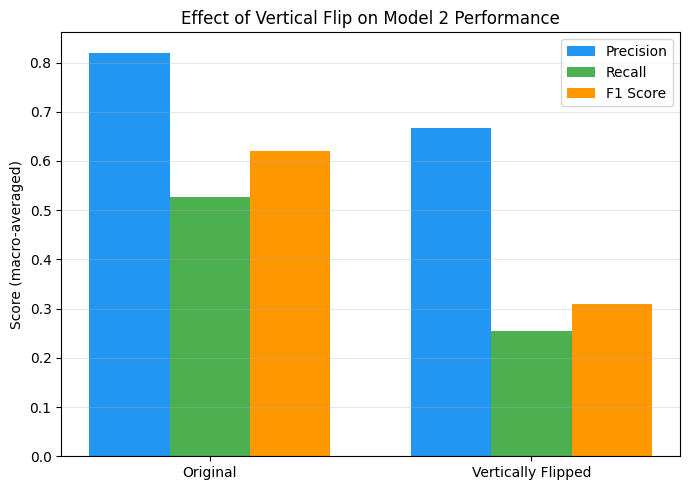

In [14]:
# Compare baseline vs vertical flip side by side
# This tells us how much the model relies on objects being "right side up"
flip_names = ["baseline", "vflip"]
flip_labels = ["Original", "Vertically Flipped"]

# Gather metrics for both conditions
flip_f1 = [all_results[n]["f1"] for n in flip_names]
flip_prec = [all_results[n]["precision"] for n in flip_names]
flip_rec = [all_results[n]["recall"] for n in flip_names]

fig, ax = plt.subplots(figsize=(7, 5))

# Grouped bar chart: precision, recall, and F1 side by side
x = np.arange(len(flip_labels))
w = 0.25

ax.bar(x - w, flip_prec, w, label="Precision", color="#2196F3")
ax.bar(x, flip_rec, w, label="Recall", color="#4CAF50")
ax.bar(x + w, flip_f1, w, label="F1 Score", color="#FF9800")

ax.set_xticks(x)
ax.set_xticklabels(flip_labels)
ax.set_ylabel("Score (macro-averaged)")
ax.set_title("Effect of Vertical Flip on Model 2 Performance")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "aug_vflip_impact.png"), dpi=150, bbox_inches="tight")
plt.show()

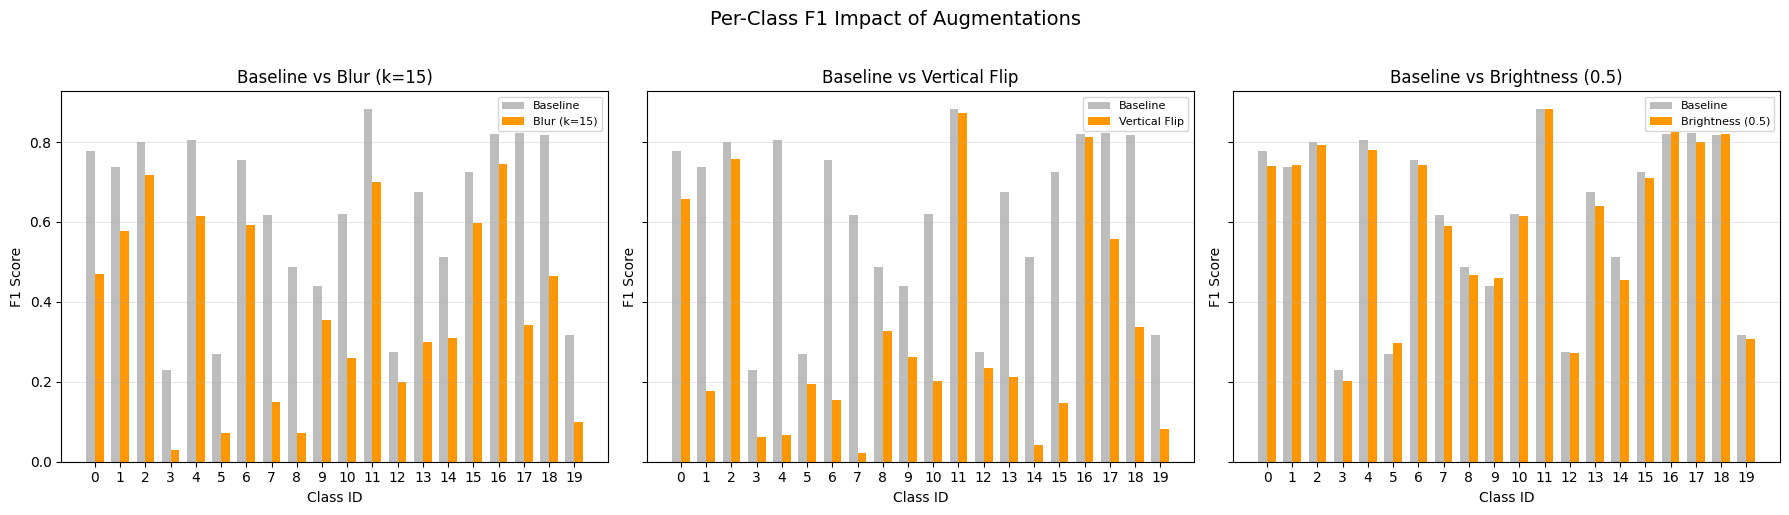

In [15]:
# Compare per-class F1 for the most impactful augmentations vs baseline
# This helps us see which specific classes get hit hardest by each distortion
baseline_df = all_results["baseline"]["df"].sort_values("class_id")

# Pick one representative augmentation from each type
compare_augs = {
    "blur_k15": "Blur (k=15)",
    "vflip": "Vertical Flip",
    "bright_0.50": "Brightness (0.5)",
}

# One subplot per augmentation, all sharing the same y-axis for easy comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (aug_key, aug_label) in zip(axes, compare_augs.items()):
    aug_df = all_results[aug_key]["df"].sort_values("class_id")

    # Side by side bars: gray = baseline, orange = augmented
    x = np.arange(20)
    w = 0.35

    ax.bar(x - w/2, baseline_df["f1"].values, w, label="Baseline", color="#BDBDBD")
    ax.bar(x + w/2, aug_df["f1"].values, w, label=aug_label, color="#FF9800")

    ax.set_xlabel("Class ID")
    ax.set_ylabel("F1 Score")
    ax.set_title(f"Baseline vs {aug_label}")
    ax.set_xticks(x)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Per-Class F1 Impact of Augmentations", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "aug_per_class_impact.png"), dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Find which classes got hurt the most by each augmentation
# This is useful for identifying the model's weak spots under specific conditions
for aug_key, aug_label in compare_augs.items():
    aug_df = all_results[aug_key]["df"].sort_values("class_id")

    # Compute the F1 drop per class (negative = got worse)
    delta = aug_df["f1"].values - baseline_df["f1"].values

    # Grab the 5 classes with the biggest F1 drop
    worst = np.argsort(delta)[:5] 

    print(f"\n{aug_label} -> classes most negatively affected:")
    for idx in worst:
        print(f"  Class {idx:2d} ({CLASS_NAMES[idx]}):  baseline F1={baseline_df['f1'].values[idx]:.3f}  ->  {aug_df['f1'].values[idx]:.3f}  (Δ={delta[idx]:+.3f})")


Blur (k=15) -> classes most negatively affected:
  Class 17 (truck):  baseline F1=0.823  ->  0.342  (Δ=-0.481)
  Class  7 (helmet):  baseline F1=0.617  ->  0.149  (Δ=-0.469)
  Class  8 (ladder):  baseline F1=0.487  ->  0.073  (Δ=-0.414)
  Class 13 (safety vest):  baseline F1=0.675  ->  0.299  (Δ=-0.375)
  Class 10 (person):  baseline F1=0.621  ->  0.260  (Δ=-0.361)

Vertical Flip -> classes most negatively affected:
  Class  4 (forklift):  baseline F1=0.804  ->  0.067  (Δ=-0.738)
  Class  6 (gloves):  baseline F1=0.755  ->  0.154  (Δ=-0.601)
  Class  7 (helmet):  baseline F1=0.617  ->  0.023  (Δ=-0.594)
  Class 15 (traffic cone):  baseline F1=0.724  ->  0.146  (Δ=-0.578)
  Class  1 (car):  baseline F1=0.738  ->  0.176  (Δ=-0.562)

Brightness (0.5) -> classes most negatively affected:
  Class 14 (smoke):  baseline F1=0.513  ->  0.454  (Δ=-0.059)
  Class  0 (barcode):  baseline F1=0.779  ->  0.740  (Δ=-0.039)
  Class 13 (safety vest):  baseline F1=0.675  ->  0.639  (Δ=-0.036)
  Class  3